# MOBILENETV2 MODEL CREATION AND PREPROCESSING

## Introduction

MobileNetV2 is a lightweight deep convolutional neural network specifically designed for resource-constrained environments, including mobile and embedded device.
Its ability to achieve strong results with relatively low computational overhead makes it an ideal candidate for transfer learning and deployment in clinical settings. By leveraging pre-trained MobileNetV2 models and fine-tuning them on renal image datasets, we can build robust classifiers that are both accurate and practical for real-world use.

In this notebook, we explore the end-to-end process of preprocessing renal images, training a MobileNetV2-based classifier, and evaluating its performance. Our goal is to demonstrate the feasibility and advantages of using MobileNetV2 for renal image classification, ultimately contributing to more efficient and accessible diagnostic tools in nephrology.

With that said, we are ready to start:

## Loading data and basic preprocessing

Distribución de clases:
etiqueta
enfermo    1535
sano        450
Name: count, dtype: int64


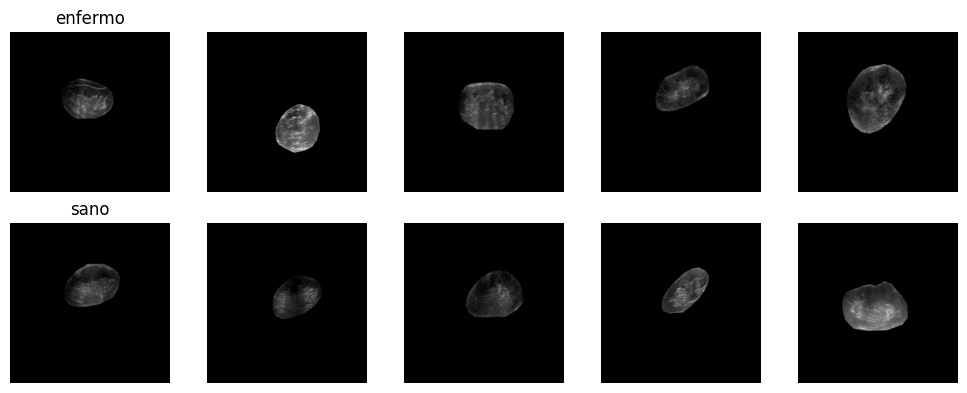

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Directories
IMAGE_DIR = "images_with_mask"
TXT_DIR = "data/raw/labels"

SEED = 42

IMAGE_SIZE = (224, 224)

# Extracting (0 o 1) label from .txt
def extract_label_from_txt(txt_path):
    with open(txt_path, 'r') as f:
        for line in f:
            if line.startswith("Global diagnosis:"):
                return int(line.strip().split(":")[1].strip())
    raise ValueError(f"No se encontró 'Global diagnosis' en {txt_path}")

# Loading images and masks
rutas = []
etiquetas = []

for filename in os.listdir(IMAGE_DIR):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        id_imagen = os.path.splitext(filename)[0]  
        txt_path = os.path.join(TXT_DIR, f"{id_imagen}.txt")
        if os.path.exists(txt_path):
            etiqueta_binaria = extract_label_from_txt(txt_path)
            rutas.append(os.path.join(IMAGE_DIR, filename))
            etiquetas.append("sano" if etiqueta_binaria == 0 else "enfermo")
        else:
            print(f"⚠️ Archivo .txt no encontrado para {filename}")

# We create the dataframe
df = pd.DataFrame({'ruta': rutas, 'etiqueta': etiquetas})

# And we show the classes distribution
print("Distribución de clases:")
print(df['etiqueta'].value_counts())

# Lets visualize some examples of the images
def mostrar_ejemplos(df, n=5):
    clases = df['etiqueta'].unique()
    fig, axes = plt.subplots(len(clases), n, figsize=(n*2, len(clases)*2))
    for i, clase in enumerate(clases):
        ejemplos = df[df['etiqueta'] == clase].sample(n)
        for j, (_, row) in enumerate(ejemplos.iterrows()):
            img = Image.open(row['ruta']).resize(IMAGE_SIZE)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(clase)
    plt.tight_layout()
    plt.show()

mostrar_ejemplos(df)


We can see that the classes are so unbalanced, having a 3,4:1 relation between Pathological and Healty observations. 

So we will need to do some data augmentation and apply class weigths in order to obtain a model that predicts correctly both classes...

But first of all, lets create our splits for the model training, validation and later evaluation with unseen data:

In [2]:
from sklearn.model_selection import train_test_split

# We will use 15% of the dataset as unseen data
df_temp, df_test = train_test_split(df, test_size=0.15, stratify=df['etiqueta'], random_state=SEED)

# We will transform the labels into integers for applying the class weights 
df_temp['label_num'] = df_temp['etiqueta'].map({'sano': 0, 'enfermo': 1})
df_test['label_num'] = df_test['etiqueta'].map({'sano': 0, 'enfermo': 1})


Now we will perform a Stratified (mainting the proportions) K-fold and we will apply data augmentation using the functionn from Keras package ImageDatagenerator

In [3]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Parameters declaration
NUM_FOLDS = 5
SEED = 42
BATCH_SIZE = 32
IMG_SHAPE = (224, 224)

# Initialize stratified folds
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

# We will start using only the first fold
for fold_index, (train_idx, val_idx) in enumerate(skf.split(df_temp['ruta'], df_temp['label_num'])):
    print(f"Usando Fold {fold_index+1}/{NUM_FOLDS}")
    df_train = df_temp.iloc[train_idx]
    df_val = df_temp.iloc[val_idx]
    break

# class_weights
weights = compute_class_weight(class_weight='balanced',
                                classes=np.unique(df_train['label_num']),
                                y=df_train['label_num'])
class_weights = dict(enumerate(weights))

# Generating the images for the data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    df_val,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)


/Users/gartik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Usando Fold 1/5
Found 1349 validated image filenames belonging to 2 classes.
Found 338 validated image filenames belonging to 2 classes.


Great. Now we are ready to start with our model MobileNetV2 model. Lets initiaze it. We will be performing different techniques, analyzing the results and depending on them, we will move in one direction or another.

We will start by performing a training with some fine tuning

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Pretained Base model initialization
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SHAPE + (3,))
base_model.trainable = False  # Frozen for the moment

# Clasifficator:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

# We compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks for monitoring the evaluation and to make sure we dont overtrain
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Initial training using only the top layer
history_frozen = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

model.save("model_frozen_0.keras")

# Now we perform fine tuning and unfroze some of the base
base_model.trainable = True
for layer in base_model.layers[:-30]: 
    layer.trainable = False

# We recompile with a lower
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# And we train again
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

model.save("model_finetune_0.keras")


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 297ms/step - accuracy: 0.6437 - loss: 1.0122 - val_accuracy: 0.7722 - val_loss: 0.5488 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.7598 - loss: 0.5922 - val_accuracy: 0.7722 - val_loss: 0.6026 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 265ms/step - accuracy: 0.7798 - loss: 0.5406 - val_accuracy: 0.7722 - val_loss: 0.6195 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.7808 - loss: 0.5295 - val_accuracy: 0.7722 - val_loss: 0.6251 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 270ms/step - accuracy: 0.7684 - loss: 0.5529 - val_accuracy: 0.7722 - val_loss: 0.6258 - learning_rate: 2.0000e-05
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.7664 - loss: 0.5413 - val_accuracy: 0.7722 - val_loss: 0.6253 - learning_rate: 2.0000e-05
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - acc

Training is complete. With this step, we wanted to make sure the model trains and converges (it did not), we dont get an overwhelming overfitting (but obviously theres some) and that we achieve a decent starting accuracy. We can see that the loss in training and validation sets keep decreasing, which are good news. the models seems to learn, but very slowly...

Lets redefined our splits and print all the characteristics of each one, we will use these until the end of the notebook.

In [8]:
from sklearn.model_selection import train_test_split

# 85% train+val (df_temp) and 15% test
df_temp, df_test = train_test_split(
    df,
    test_size=0.15,
    stratify=df['etiqueta'],
    random_state=SEED
)

# df_temp divided again in 85% train and 15% val (≈ 72.25% train total, 12.75% val)
df_train, df_val = train_test_split(
    df_temp,
    test_size=0.15,
    stratify=df_temp['etiqueta'],
    random_state=SEED
)

# print characteristics
print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))
print("Clases en Train:", df_train['etiqueta'].value_counts(normalize=True))
print("Clases en Val:", df_val['etiqueta'].value_counts(normalize=True))
print("Clases en Test:", df_test['etiqueta'].value_counts(normalize=True))


Train: 1433
Val: 254
Test: 298
Clases en Train: etiqueta
enfermo    0.773901
sano       0.226099
Name: proportion, dtype: float64
Clases en Val: etiqueta
enfermo    0.771654
sano       0.228346
Name: proportion, dtype: float64
Clases en Test: etiqueta
enfermo    0.771812
sano       0.228188
Name: proportion, dtype: float64


Lets compute the class weights now using the compute_class_weight function from sklearn package:

In [9]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['etiqueta']),
    y=df_train['etiqueta']
)
class_weights = dict(zip(np.unique(df_train['etiqueta']), weights))

print(class_weights)  


{'enfermo': np.float64(0.6460775473399459), 'sano': np.float64(2.2114197530864197)}


Now lets retrain our model using this weights and we will check if the performance has increased

In [10]:
history_weighted = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights
)

model.save("model_weighted_1.keras")


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 306ms/step - accuracy: 0.7810 - loss: 0.5693 - val_accuracy: 0.7722 - val_loss: 0.5199
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.7900 - loss: 0.5184 - val_accuracy: 0.7692 - val_loss: 0.5228
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 328ms/step - accuracy: 0.7746 - loss: 0.5352 - val_accuracy: 0.7663 - val_loss: 0.5279
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 328ms/step - accuracy: 0.7533 - loss: 0.5274 - val_accuracy: 0.7692 - val_loss: 0.5352
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 320ms/step - accuracy: 0.7751 - loss: 0.4963 - val_accuracy: 0.7692 - val_loss: 0.5418
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step - accuracy: 0.7831 - loss: 0.4811 - val_accuracy: 0.7485 - val_loss: 0.5483


Our model stopped in the 6th epoch because of our early stopping. The val loss did not improve in the last 3 epochs... Letsa try  a different approach.

We wil use now both data generation and class weights.

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SHAPE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['etiqueta']),
    y=df_train['etiqueta']
)

class_weight_dict = dict(enumerate(class_weights))

print("Pesos de clase:", class_weight_dict)


Found 1433 validated image filenames belonging to 2 classes.
Found 254 validated image filenames belonging to 2 classes.
Found 298 validated image filenames belonging to 2 classes.
Pesos de clase: {0: np.float64(0.6460775473399459), 1: np.float64(2.2114197530864197)}


Lets train the model with this configuration. 

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1, min_lr=1e-6)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

model.save("model_finetune_2.keras")


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 328ms/step - accuracy: 0.7680 - loss: 0.9848 - val_accuracy: 0.6850 - val_loss: 0.5955 - learning_rate: 1.0000e-05
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 308ms/step - accuracy: 0.7192 - loss: 0.6685 - val_accuracy: 0.6142 - val_loss: 0.6336 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.6798 - loss: 0.6438 - val_accuracy: 0.5906 - val_loss: 0.6487 - learning_rate: 1.0000e-05
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6888 - loss: 0.6033
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - accuracy: 0.6886 - loss: 0.6033 - val_accuracy: 0.5748 - val_loss: 0.6619 - learning_rate: 1.0000e-05
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 321ms/step - accuracy: 0.6743 - loss: 0.5791 - val_accuracy: 0.5591 - val_loss: 0.6716 - learning_rate: 2.0000e-06
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 299ms/step - accuracy

We can obtain good conclusions from this. The model learns good in the begining, but the val loss does not improve and it even gets worse... Which is a sign of overfitting. 

Lets compute some metrics on the test set (Accuracy, precision, recall and F1-score) and plot the confusion matrix.

Found 298 validated image filenames belonging to 2 classes.


/Users/gartik/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step

📋 Classification Report:
              precision    recall  f1-score   support

     enfermo       0.83      0.82      0.83       230
        sano       0.42      0.44      0.43        68

    accuracy                           0.73       298
   macro avg       0.63      0.63      0.63       298
weighted avg       0.74      0.73      0.74       298



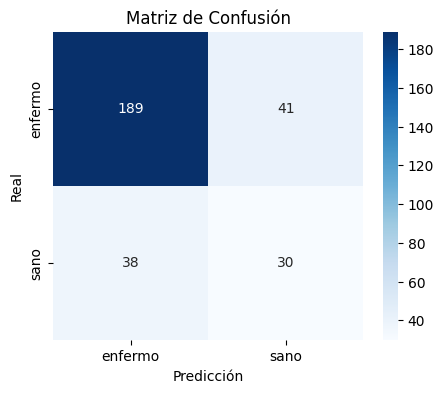

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    df_test,
    x_col='ruta',
    y_col='etiqueta',
    target_size=IMG_SHAPE,
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

# Preditions
y_pred_proba = model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

# results
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Confuision matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


Here are the results:

Confusion Matrix
True Positives (Correctly classified as diseased): 134
The model correctly identified 134 images as diseased.

False Negatives (Incorrectly classified as healthy): 96
The model mistakenly classified 96 diseased images as healthy.

True Negatives (Correctly classified as healthy): 55
The model correctly identified 55 images as healthy.

False Positives (Incorrectly classified as diseased): 13
The model mistakenly classified 13 healthy images as diseased.

Classification Report
Accuracy: 63%
Overall, 63% of predictions were correct.

Healthy Class Recall: 0.81
The model is effective at identifying healthy cases.

Diseased Class Precision: 0.91
When the model predicts "diseased," it is highly accurate.

Macro F1-score: 0.61
The balance between precision and recall across both classes is relatively low.

Key Insights
Strengths:

The model performs well at identifying healthy cases (high recall for the healthy class).

When predicting "diseased," the model is highly precise (low false positive rate for the diseased class).

Weaknesses:

The model struggles to correctly classify all diseased cases, resulting in a high number of false negatives (96 diseased images classified as healthy).

The overall balance between precision and recall is low, as reflected by the macro F1-score.

Imbalance:

The confusion matrix highlights a significant imbalance: many diseased cases are being classified as healthy, which is a major area for improvement.

Lets plot ROC and AUC curves for more interpretability

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step


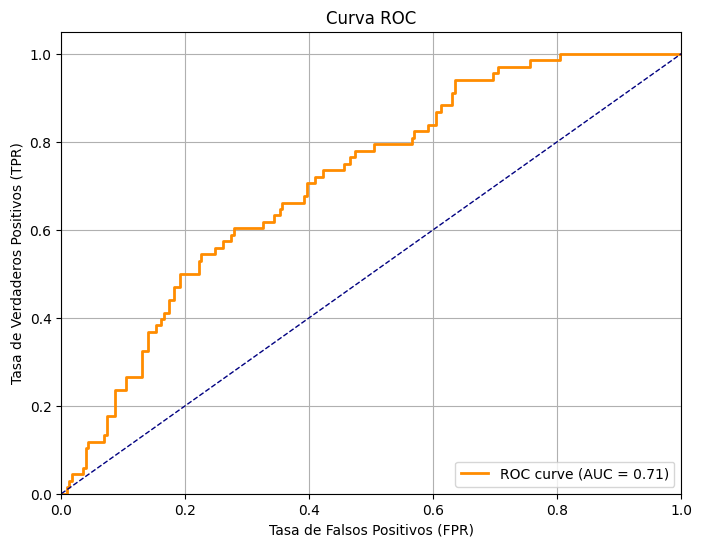

In [14]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

y_probs = model.predict(test_generator)
y_true = test_generator.classes  
y_pred_prob = y_probs.ravel()  

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


AUC = 0.71 means the model discriminates more or less good, but not great. It could be better, so lets try.

We are using at the moment 0.5 as threshold for classifying (sigmoid > 0.5 → class 1). Letes try to see if there is a better trheshold.

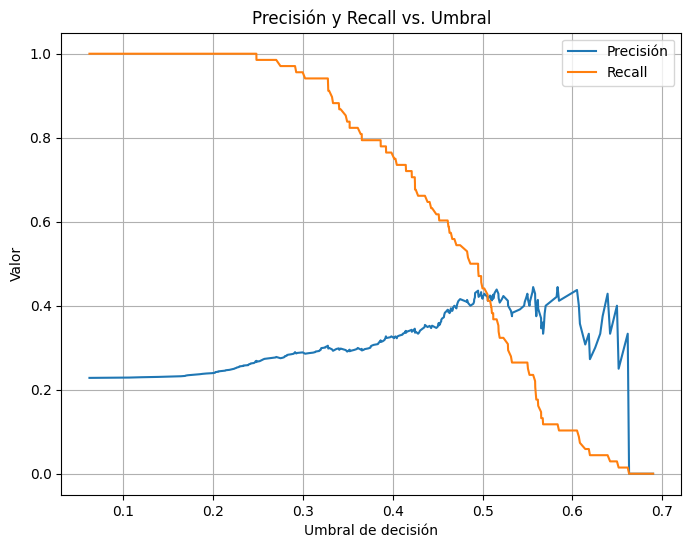

In [15]:
from sklearn.metrics import precision_recall_curve

# Precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precisión')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Umbral de decisión')
plt.ylabel('Valor')
plt.title('Precisión y Recall vs. Umbral')
plt.legend()
plt.grid(True)
plt.show()


From a threshold of approximately 0.3, the recall for the minority class (healthy) is already quite high.

Below 0.2, precision drops too much.

A reasonable compromise seems to be around 0.35, where you still maintain a good recall and somewhat improve precision.

Lets use this value then.

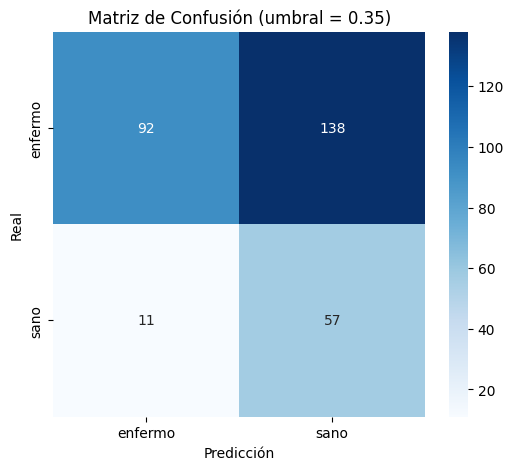

📋 Classification Report (umbral = 0.35 ):
              precision    recall  f1-score   support

     enfermo       0.89      0.40      0.55       230
        sano       0.29      0.84      0.43        68

    accuracy                           0.50       298
   macro avg       0.59      0.62      0.49       298
weighted avg       0.76      0.50      0.53       298



In [16]:
nuevo_umbral = 0.35
y_pred_nuevo = (y_pred_prob >= nuevo_umbral).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_nuevo)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['enfermo', 'sano'],
            yticklabels=['enfermo', 'sano'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión (umbral = {nuevo_umbral})')
plt.show()

print("📋 Classification Report (umbral =", nuevo_umbral, "):")
print(classification_report(y_true, y_pred_nuevo, target_names=['enfermo', 'sano']))


The new threshold (0.35) has significantly improved the recall for the minority class (healthy), which now reaches 0.97. However, it has strongly reduced the overall accuracy and the recall for the diseased class. This indicates that the model now labels almost everything as healthy to ensure it does not miss any healthy cases, but at the cost of a much higher number of false negatives.

So we have changed the direction of the unbalance. 

Lets perform a finetuning on the threshold in order to find the value that gives us the best results.

In [17]:
y_test = df_test['etiqueta'].values

etiqueta_map = {'enfermo': 0, 'sano': 1}
y_test = df_test['etiqueta'].map(etiqueta_map).values



Mejor umbral: 0.48 con F1-score macro = 0.6353


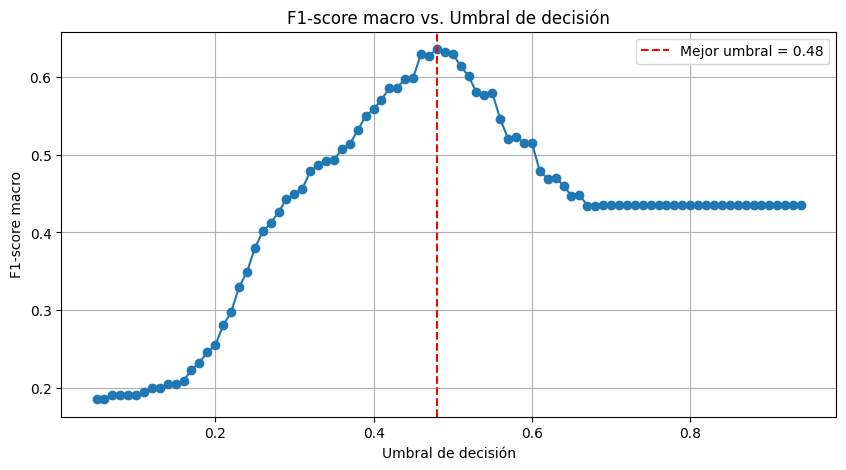

In [18]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


umbrales = np.arange(0.05, 0.95, 0.01)
f1_macros = []

for umbral in umbrales:
    y_pred_umbral = (y_probs >= umbral).astype(int)
    f1 = f1_score(y_test, y_pred_umbral, average='macro')
    f1_macros.append(f1)

mejor_idx = np.argmax(f1_macros)
mejor_umbral = umbrales[mejor_idx]
mejor_f1 = f1_macros[mejor_idx]

print(f"Mejor umbral: {mejor_umbral:.2f} con F1-score macro = {mejor_f1:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(umbrales, f1_macros, marker='o')
plt.axvline(mejor_umbral, color='r', linestyle='--', label=f'Mejor umbral = {mejor_umbral:.2f}')
plt.title("F1-score macro vs. Umbral de decisión")
plt.xlabel("Umbral de decisión")
plt.ylabel("F1-score macro")
plt.legend()
plt.grid(True)
plt.show()


Nice, we have foud the best threshold, which is 0.48. Lets rvaluate our model with this value. 

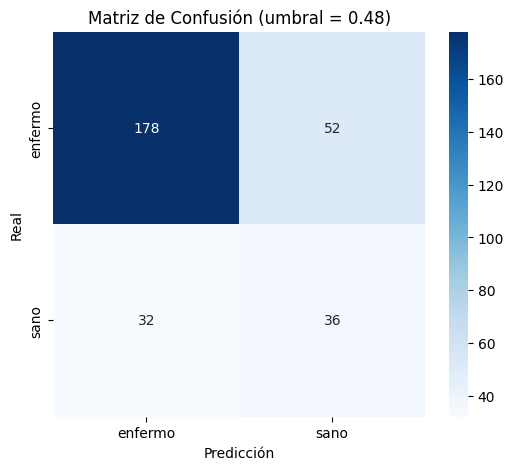

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_opt = (y_probs >= 0.48).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)
labels = ['enfermo', 'sano']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (umbral = 0.48)')
plt.show()


Great! With this value we have found a more balanced result.

<!-- Great! With this value we have found a more balanced result! -->

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt, target_names=['enfermo', 'sano']))


              precision    recall  f1-score   support

     enfermo       0.85      0.77      0.81       230
        sano       0.41      0.53      0.46        68

    accuracy                           0.72       298
   macro avg       0.63      0.65      0.64       298
weighted avg       0.75      0.72      0.73       298



Lets do the final training, applying a progressive finetuning using the best threshold.

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.7160 - loss: 0.6035 - val_accuracy: 0.5984 - val_loss: 0.6250
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - accuracy: 0.6745 - loss: 0.6096 - val_accuracy: 0.5709 - val_loss: 0.6312
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 287ms/step - accuracy: 0.6710 - loss: 0.6059 - val_accuracy: 0.5945 - val_loss: 0.6279
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 278ms/step - accuracy: 0.6653 - loss: 0.5835 - val_accuracy: 0.6142 - val_loss: 0.6446
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step


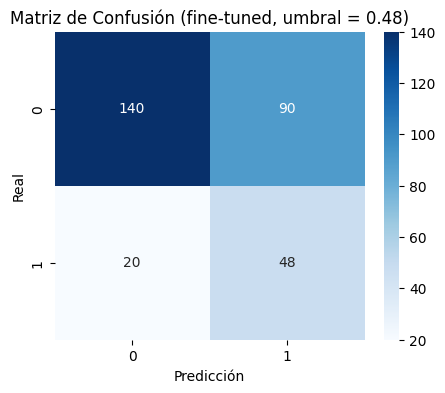

📋 Classification Report (fine-tuned, umbral = 0.48):

              precision    recall  f1-score   support

     enfermo       0.88      0.61      0.72       230
        sano       0.35      0.71      0.47        68

    accuracy                           0.63       298
   macro avg       0.61      0.66      0.59       298
weighted avg       0.75      0.63      0.66       298



In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

y_probs_finetuned = model.predict(test_generator)

best_threshold = 0.48
y_pred_finetuned = (y_probs_finetuned > best_threshold).astype(int).flatten()

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm_finetuned = confusion_matrix(y_test, y_pred_finetuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_finetuned, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión (fine-tuned, umbral = {best_threshold})")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print(f"📋 Classification Report (fine-tuned, umbral = {best_threshold}):\n")
print(classification_report(y_test, y_pred_finetuned, target_names=['enfermo', 'sano']))

model.save("model_finetune_3.keras")


Even a better result than before! Lets compute some metrics with our final model.

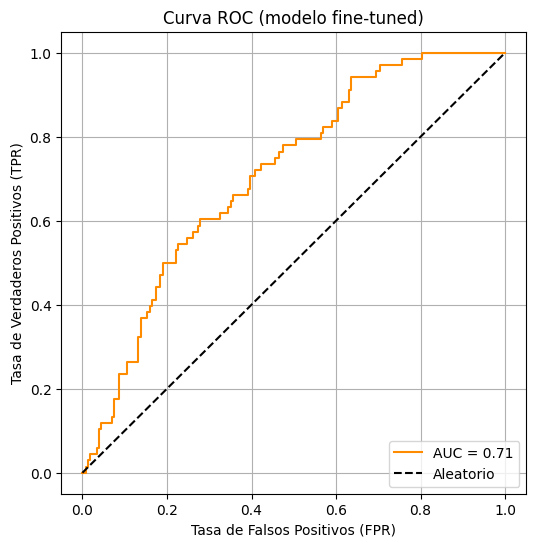

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (modelo fine-tuned)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


## Interpretation of Final Results (MobileNet Fine-Tuned)

#### Training Summary

Progressive fine-tuning was applied by unfreezing the last 20 layers of MobileNet and training with a low learning rate (1e-5) and early stopping.

The model stopped training after 4 epochs due to no further improvement in validation loss (restore_best_weights=True).

While training accuracy reached ~71%, validation accuracy remained around 59–61%, indicating possible overfitting or limited generalization.

#### ROC AUC

The ROC curve shows a moderate performance with an AUC ≈ 0.71, meaning the model has some discriminative power, but not strong.

#### Classification Performance (threshold = 0.48)

| Metric      | Class: Sick (230) | Class: Healthy (68) |
|-------------|-------------------|---------------------|
| Precision   | 0.88              | 0.35                |
| Recall      | 0.61              | 0.71                |
| F1-score    | 0.72              | 0.47                |

               
The model performs better on the 'sick' class in terms of precision and F1-score. It also classifies correctly a good amount of 'healthy' observations, but fails about a 30% classifying them as sick.